In [31]:
from matplotlib import pyplot as plt

import gradio as gr
from PIL import Image
import io
import numpy as np

%matplotlib inline

In [1]:
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet(root='./data', download=True)
print(f"Total images: {len(dataset)}")
print(f"Classes ({len(dataset.classes)}): {dataset.classes}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 792M/792M [01:56<00:00, 6.79MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19.2M/19.2M [00:02<00:00, 7.55MB/s]


Total images: 3680
Classes (37): ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [2]:
print(type(dataset))
print(dir(dataset))
print(dataset[0])  # should return (image_tensor, label_int)

<class 'torchvision.datasets.oxford_iiit_pet.OxfordIIITPet'>
['_RESOURCES', '_VALID_TARGET_TYPES', '__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_anns_folder', '_base_folder', '_bin_labels', '_check_exists', '_download', '_format_transform_repr', '_images', '_images_folder', '_is_protocol', '_labels', '_repr_indent', '_segs', '_segs_folder', '_split', '_target_types', 'bin_class_to_idx', 'bin_classes', 'class_to_idx', 'classes', 'extra_repr', 'root', 'target_transform', 'transform', 'transforms']
(<PIL.Image.Image image mode=RGB size=394x500 at 0x195E95

Showing: 'Newfoundland' (class 22)


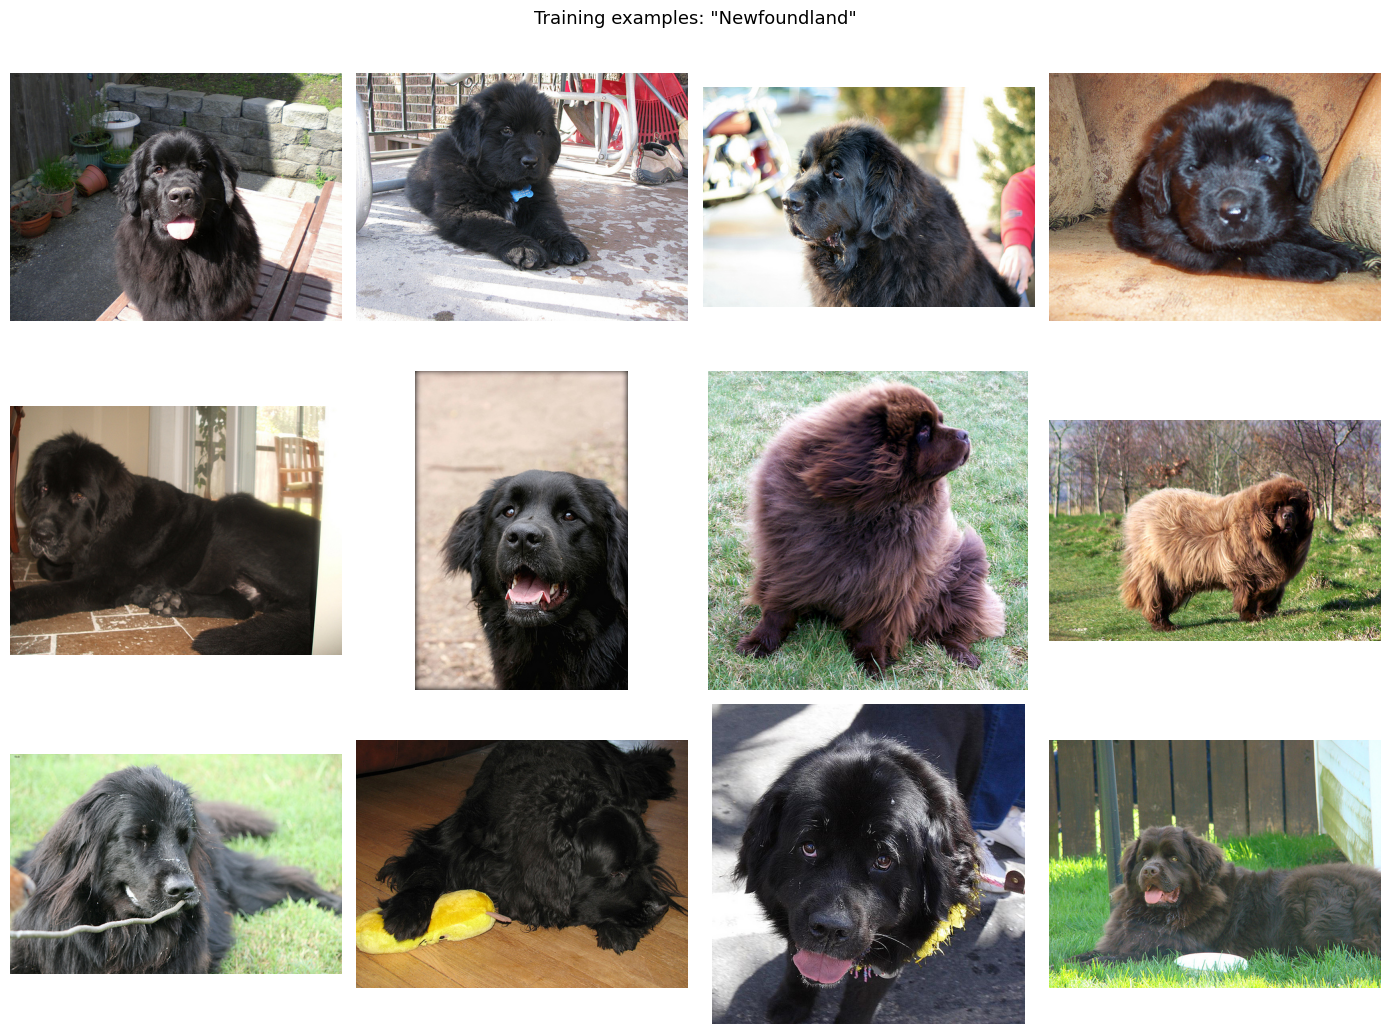

Showing: 'Siamese' (class 32)


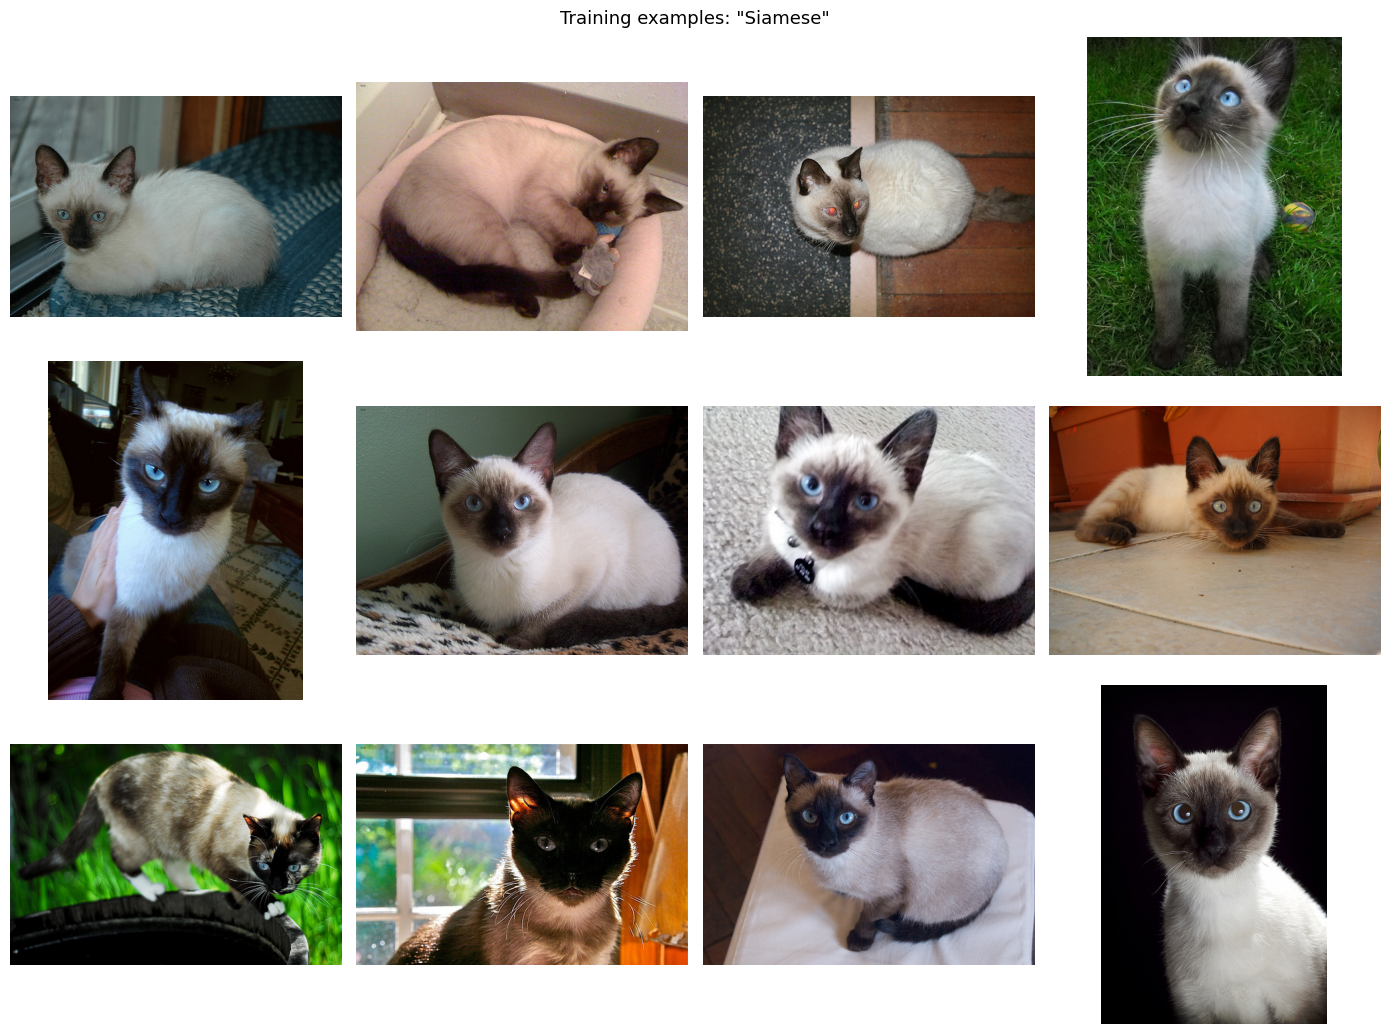

In [10]:
# _images is a list of (image_path, label_idx) tuples
# _labels is the label list
# classes is the class name list

def show_pet_examples(class_name, n=12):
    query = class_name.lower().replace(' ', '_').replace('-', '_')
    
    # Find matching class index
    matches = [(i, c) for i, c in enumerate(dataset.classes)
               if query in c.lower().replace('-','_') 
               or c.lower().replace('-','_') in query]
    
    if not matches:
        print(f"Not found: '{class_name}'")
        print(f"Available classes: {dataset.classes}")
        return
    
    class_idx, matched_name = matches[0]
    print(f"Showing: '{matched_name}' (class {class_idx})")
    
    # Find image indices for this class
    indices = [i for i, label in enumerate(dataset._labels)
               if label == class_idx]
    
    # Take random sample
    import random
    sample = random.sample(indices, min(n, len(indices)))
    
    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.5*cols, 3.5*rows))
    fig.suptitle(f'Training examples: "{matched_name}"', fontsize=13)
    
    for ax, idx in zip(axes.flat, sample):
        img, _ = dataset[idx]  # returns PIL image since no transform set
        ax.imshow(img)
        ax.axis('off')
    for ax in axes.flat[len(sample):]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Test
show_pet_examples("Newfoundland")
show_pet_examples("Siamese")

In [7]:
for i, name in enumerate(dataset.classes):
    print(f"{i:2d}: {name}")

 0: Abyssinian
 1: American Bulldog
 2: American Pit Bull Terrier
 3: Basset Hound
 4: Beagle
 5: Bengal
 6: Birman
 7: Bombay
 8: Boxer
 9: British Shorthair
10: Chihuahua
11: Egyptian Mau
12: English Cocker Spaniel
13: English Setter
14: German Shorthaired
15: Great Pyrenees
16: Havanese
17: Japanese Chin
18: Keeshond
19: Leonberger
20: Maine Coon
21: Miniature Pinscher
22: Newfoundland
23: Persian
24: Pomeranian
25: Pug
26: Ragdoll
27: Russian Blue
28: Saint Bernard
29: Samoyed
30: Scottish Terrier
31: Shiba Inu
32: Siamese
33: Sphynx
34: Staffordshire Bull Terrier
35: Wheaten Terrier
36: Yorkshire Terrier


In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms as T

# Load fine-tuned model
checkpoint = torch.load('oxford_pets_resnet50.pth', map_location='cpu')
class_names = checkpoint['class_names']
num_classes = len(class_names)

model = resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded. Val accuracy: {checkpoint['val_accuracy']:.1%}")

transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

Loaded. Val accuracy: 92.9%


In [41]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn.functional as F

# Hook to capture the last conv layer output
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        target = self.model.layer4[-1].conv3
        target.register_forward_hook(forward_hook)
        target.register_full_backward_hook(backward_hook)

    def compute(self, tensor, class_idx):
        self.model.zero_grad()
        # requires_grad must be set HERE, on a fresh tensor
        inp = tensor.detach().requires_grad_(True)
        out = self.model(inp)
        out[0, class_idx].backward()

        if self.gradients is None:
            print("WARNING: gradients are None — hooks not firing")
            return np.zeros((224, 224))

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)
        cam = torch.nn.functional.interpolate(
            cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam = cam[0, 0].numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        print(f"activations: {self.activations.shape if self.activations is not None else None}")
        print(f"gradients: {self.gradients.shape if self.gradients is not None else None}")
        print(f"cam min/max before norm: {cam.min():.4f}/{cam.max():.4f}")

        return cam

gradcam = GradCAM(model)

In [44]:
def fig_to_numpy(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    plt.close(fig)  # free memory
    return np.array(img)

def classify_with_explanation(img):
    if img is None:
        return {}, None, None

    pil_img = Image.fromarray(img[:, :, :3]).convert('RGB')

    tensor = transform(pil_img).unsqueeze(0)
    # tensor.requires_grad_(True)

    # Forward pass
    with torch.enable_grad():
        out = model(tensor)
    probs = torch.softmax(out[0], dim=0)
    top5_probs, top5_ids = torch.topk(probs, 5)
    result = {class_names[i].replace('_', ' '): float(p)
          for i, p in zip(top5_ids.detach(), top5_probs.detach())}
    predicted_idx = int(top5_ids[0])
    predicted_label = class_names[predicted_idx]

    debug_t = T.Compose([T.Resize(256), T.CenterCrop(224)])
    debug_pil = debug_t(pil_img)
    debug_arr = np.array(debug_pil)
    
    # GradCAM — single backward pass, very fast
    cam = gradcam.compute(tensor, predicted_idx)

    # Figure
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    fig.suptitle(f'"{predicted_label.replace("_"," ")}"  '
                 f'({float(top5_probs[0]):.0%})', fontsize=13)
    #ax.imshow(debug_arr)
    #ax.imshow(cam, cmap='jet', alpha=0.6, vmin=0, vmax=1)
    ax.imshow(debug_arr, extent=[0, 224, 224, 0])
    ax.imshow(cam, cmap='jet', alpha=0.6, vmin=0, vmax=1,
              extent=[0, 224, 224, 0])
    ax.set_title("Where it looked (GradCAM)", fontsize=10)
    ax.axis('off')

    plt.tight_layout()
    return result, fig_to_numpy(fig)

with gr.Blocks(title="What does the AI see?") as demo:
    gr.Markdown("## 🔍 What does the AI see?")
    gr.Markdown("**Step 1:** take a snapshot or upload. **Step 2:** click Classify.")

    with gr.Tab("📷 Camera"):
        gr.Markdown("👆 Click the **camera icon** inside the box below to capture a frame first, then click Classify.")
        cam_input = gr.Image(
            sources=["webcam"],
            type="numpy",
            label="1. Capture a frame first",
        )
        cam_output = gr.Label(num_top_classes=5, label="AI's guess")
        classify_btn_cam = gr.Button("Classify ▶", variant="primary")
        shap_plot_cam = gr.Image(label="Explanation", width=500, height=500)

        classify_btn_cam.click(
            fn=classify_with_explanation,
            inputs=cam_input,
            outputs=[cam_output, shap_plot_cam]
        )

    with gr.Tab("📁 Upload"):
        up_input = gr.Image(
            sources=["upload"],
            type="numpy",
            label="Upload any photo",
        )
        up_output = gr.Label(num_top_classes=5, label="AI's guess")
        classify_btn_upl = gr.Button("Classify ▶", variant="primary")
        shap_plot_upl = gr.Image(label="Explanation", width=500, height=500)

        classify_btn_upl.click(
            fn=classify_with_explanation,
            inputs=up_input,
            outputs=[up_output, shap_plot_upl]
        )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862

Could not create share link. Missing file: C:\Users\andre\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\andre\.cache\huggingface\gradio\frpc


activations: torch.Size([1, 2048, 7, 7])
gradients: torch.Size([1, 2048, 7, 7])
cam min/max before norm: 0.0000/1.0000
activations: torch.Size([1, 2048, 7, 7])
gradients: torch.Size([1, 2048, 7, 7])
cam min/max before norm: 0.0000/1.0000


In [43]:
gr.close_all()

Closing server running on port: 7862
